# M3 Program 3: Dynamic Programming

CSC3310

Names: Madison Betz, Chukwuma Chukwuma-Ugwu, Sam Schoenfeld

## Approach
To solve the MAXIMALSUBSTRING problem, we identify the longest string that is a contiguous substring of both input strings a and b. Our strategy follows a three-stage evolution: starting with a recursive backtracking algorithm to test potential character matches, moving to a memoized version that stores the results in an array to eliminate redundant calculations, and finally implementing an eager dynamic programming solution. The core logic focuses on substrings ending at a specific pair of characters (i,j). If the characters a[i] and b[j] match, the length of the common substring is 1+ the value of the diagonal neighbor (i - 1, j - 1); otherwise, the length is 0. By iteratively filling a 2D table using this rule, the algorithm efficiently finds the maximum length and returns the corresponding substring.

### Illustration 1
This diagram visualizes how the value of each cell in the dynamic programming table is derived. A match at the current indices (i,j) steps up the value from the previous diagonal state, representing the continuation of a common substring.

![logic](logic.png)

### Illustration 2
This table demonstrates the "eager" filling process. The algorithm tracks the highest value in the table and its location to get the final result.

![table](table.png)

## Pseudocode

### Backtracking (Recursive)
Method LCS_Backtrack(a, b, i, j)
1. If i < 0 or j < 0, return 0
2. If a[i] == b[j]: return 1 + LCS_Backtrack(a, b, i - 1, j - 1)
3. Else: return 0

### Memoized (Lazy Dynamic Programming)
Initialize memo table of size n x m with -1 <br>
Algorithm LCS_Memo(a, b, i, j)
1. If i < 0 or j < 0 return 0
2.    If memo[i][j] != -1: return memo[i][j]
3. If a[i] == b[j]: memo[i][j] = 1 + LCS_Memo(a, b, i - 1, j - 1)
4. Else: memo[i][j] = 0
5. Return memo[i][j]

### Eager Dynamic Programming
Algorithm MAX_SUBSTRING(a, b)
1. Let n = |a|, m = |b|
2. Create a 2D array Table of size (n + 1) x (m + 1) initialized to 0
3. maxLength = 0, endIndex = 0
4. For i from 1 to n: For j from 1 to m:
5. If a[i - 1] == b[j - 1]: Table[i][j] = Table[i - 1][j - 1] + 1
6. If Table[i][j] > maxLength: maxLength = Table[i][j], endIndex = i
7. Else: Table[i][j] = 0
8. Return the slice of a from endIndex - maxLength to endIndex


In [1]:
def lcs_backtrack(a, b, i, j):
    if i < 0 or j < 0:
        return 0
    if a[i] == b[j]:
        return 1 + lcs_backtrack(a, b, i - 1, j - 1)
    return 0

def get_maximal_backtrack(a, b):
    max_len = 0
    end_idx = 0
    for i in range(len(a)):
        for j in range(len(b)):
            current_len = lcs_backtrack(a, b, i, j)
            if current_len > max_len:
                max_len = current_len
                end_idx = i + 1
    return a[end_idx - max_len : end_idx]

In [2]:
def get_maximal_memoized(a, b):
    n, m = len(a), len(b)
    memo = [[-1 for _ in range(m)] for _ in range(n)]

    def lcs_memo(i, j):
        if i < 0 or j < 0:
            return 0
        if memo[i][j] != -1:
            return memo[i][j]

        if a[i] == b[j]:
            memo[i][j] = 1 + lcs_memo(i - 1, j - 1)
        else:
            memo[i][j] = 0
        return memo[i][j]

    max_len = 0
    end_idx = 0
    for i in range(n):
        for j in range(m):
            current_len = lcs_memo(i, j)
            if current_len > max_len:
                max_len = current_len
                end_idx = i + 1
    return a[end_idx - max_len : end_idx]

In [3]:
def get_maximal_eager_dp(a, b):
    n, m = len(a), len(b)
    table = [[0 for _ in range(m + 1)] for _ in range(n + 1)]
    max_len = 0
    end_idx = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if a[i-1] == b[j-1]:
                table[i][j] = table[i-1][j-1] + 1
                if table[i][j] > max_len:
                    max_len = table[i][j]
                    end_idx = i
            else:
                table[i][j] = 0

    return a[end_idx - max_len : end_idx]

## Justification of Correctness

The backtracking algorithm is correct because `lcs_backtrack(a, b, i, j)` returns exactly the length of the longest common substring ending at index `i` in `a` and index `j` in `b`. This can be proven by induction on the sum `i + j`. The base case holds: when either index is negative, no substring is possible, so 0 is returned. For the inductive step, if `a[i] == b[j]`, the two characters form a common endpoint and the problem reduces to extending whatever shared suffix ended at `(i-1, j-1)` — which the recursive call computes correctly by the inductive hypothesis. If `a[i] != b[j]`, no common substring can end at both `i` and `j`, so 0 is returned. The outer loops in `get_maximal_backtrack` exhaustively try every possible ending pair `(i, j)`, and the maximum over all pairs gives the globally longest common substring, which is reconstructed via a slice.

The memoized algorithm is correct for the same reason: it computes the identical recurrence, and memoization only caches results to avoid redundant recomputation. Because each call to `lcs_memo(i, j)` depends only on `lcs_memo(i-1, j-1)` — strictly "earlier" in the diagonal — there are no circular dependencies, and every subproblem is evaluated exactly once. The value retrieved from or stored in the memo table always matches what plain recursion would return, so correctness is fully inherited from the backtracking argument.

The eager dynamic programming algorithm is correct by induction on the order in which the table is filled. The invariant is that `table[i][j]` holds the length of the longest common substring of `a` and `b` that ends exactly at `a[i-1]` and `b[j-1]`. The boundary (row 0 and column 0) is initialized to 0, satisfying the base case. When the table is filled row-by-row, `table[i-1][j-1]` is always computed before `table[i][j]`, so the diagonal dependency is always satisfied. If `a[i-1] == b[j-1]`, the value extends the diagonal; otherwise it resets to 0, exactly matching the recurrence. Maintaining `maxLength` and `endIndex` at every step ensures the globally maximal value and its location are captured, and the final slice correctly reconstructs the substring.


## Test Cases

The table below shows each test case, the expected output, and the actual results from all three algorithm implementations. For the "pinaeapple" / "orange" case, the expected result is any single character from the set {`"n"`, `"a"`, `"e"`} — the algorithm returns the first maximal match it encounters.

| String a | String b | Expected | Backtrack | Memoized | Eager DP |
|---|---|---|---|---|---|
| `"orange"` | `"banana"` | `"an"` | `"an"` | `"an"` | `"an"` |
| `"banana"` | `"apple"` | `"a"` | `"a"` | `"a"` | `"a"` |
| `"apple"` | `"pineapple"` | `"apple"` | `"apple"` | `"apple"` | `"apple"` |
| `"pinaeapple"` | `"orange"` | `"n"`, `"a"`, or `"e"` | `"n"` | `"n"` | `"n"` |
| `"abc"` | `"xyz"` | `""` | `""` | `""` | `""` |
| `"aaa"` | `"aa"` | `"aa"` | `"aa"` | `"aa"` | `"aa"` |
| `"a"` | `"a"` | `"a"` | `"a"` | `"a"` | `"a"` |

The code cell below confirms these results programmatically.


In [4]:
test_cases = [
    ("orange", "banana", "an"),
    ("banana", "apple", "a"),
    ("apple", "pineapple", "apple"),
    ("pinaeapple", "orange", None), 
    ("abc", "xyz", ""),
    ("aaa", "aa", "aa"),
    ("a", "a", "a"),
]

print(f"{'String a':<14} {'String b':<12} {'Expected':<14} {'Backtrack':<12} {'Memoized':<12} {'Eager DP'}")
print("-" * 76)
for a, b, expected in test_cases:
    bt    = get_maximal_backtrack(a, b)
    memo  = get_maximal_memoized(a, b)
    eager = get_maximal_eager_dp(a, b)
    exp_str = "len=1 match" if expected is None else repr(expected)
    ok = all([
        (len(bt) >= 1 if expected is None else bt == expected),
        (len(memo) >= 1 if expected is None else memo == expected),
        (len(eager) >= 1 if expected is None else eager == expected),
    ])
    status = "PASS" if ok else "FAIL"
    print(f"{repr(a):<14} {repr(b):<12} {exp_str:<14} {repr(bt):<12} {repr(memo):<12} {repr(eager):<12} {status}")


String a       String b     Expected       Backtrack    Memoized     Eager DP
----------------------------------------------------------------------------
'orange'       'banana'     'an'           'an'         'an'         'an'         PASS
'banana'       'apple'      'a'            'a'          'a'          'a'          PASS
'apple'        'pineapple'  'apple'        'apple'      'apple'      'apple'      PASS
'pinaeapple'   'orange'     len=1 match    'n'          'n'          'n'          PASS
'abc'          'xyz'        ''             ''           ''           ''           PASS
'aaa'          'aa'         'aa'           'aa'         'aa'         'aa'         PASS
'a'            'a'          'a'            'a'          'a'          'a'          PASS


## Asymptotic Runtime

**Backtracking** (`get_maximal_backtrack`)

The outer double loop over all pairs $(i, j)$ runs in $O(nm)$ iterations. At each pair, `lcs_backtrack` recurses diagonally along the $(i-1, j-1)$ chain. In the worst case (all characters match), this chain has depth $\min(i, j) \leq \min(n, m)$, with $O(1)$ work per call. Therefore:

$$T(n, m) = O\!\left(nm \cdot \min(n, m)\right)$$

**Memoized** (`get_maximal_memoized`)

There are $n \cdot m$ distinct subproblems. Each subproblem `lcs_memo(i, j)` is computed at most once — subsequent accesses are an $O(1)$ table lookup — and each computation does $O(1)$ work (one character comparison plus one recursive call that immediately returns from the memo). The outer loops add another $O(nm)$ factor, which does not change the overall bound:

$$T(n, m) = O(nm)$$

**Eager Dynamic Programming** (`get_maximal_eager_dp`)

The algorithm fills an $(n+1) \times (m+1)$ table with two nested loops. Each of the $O(nm)$ cells requires exactly one character comparison and one table read — both $O(1)$. There is no recursion overhead or memoization dictionary involved:

$$T(n, m) = O(nm)$$

**Summary:** Eager DP and Memoized are both $O(nm)$, matching the $\Omega(nm)$ lower bound on this problem (every cell corresponds to a potentially necessary character comparison). Eager DP is faster in practice due to lower constant factors. Backtracking is strictly worse at $O(nm \cdot \min(n, m))$, effectively cubic when $n \approx m$.


## Benchmarking

### Helper Functions

In [68]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import random
import string


def generate_string(length):
    return ''.join(random.choices(string.ascii_lowercase, k=length))

def get_runtime(func, a, b):
    times = []
    for _ in range(10):
        start = time.perf_counter()
        func(a, b)
        end = time.perf_counter()
        times.append(end - start)
    return sum(times) / len(times)

# Generates 2 seperate, random strings
def run_benchmarks1(a_length, b_length):
    a = generate_string(a_length)
    b = generate_string(b_length)
    backtrack_time = get_runtime(get_maximal_backtrack, a, b)
    memoized_time = get_runtime(get_maximal_memoized, a, b)
    eager_time = get_runtime(get_maximal_eager_dp, a, b)
    return {
        'A Length': a_length,
        'B Length': b_length,
        'Backtrack': backtrack_time,
        'Memoized': memoized_time,
        'Eager': eager_time
    }

# Generates 2 identical strings to analyze worst case
def run_benchmarks2(a_length, b_length):
    a = "a" * a_length
    b = "a" * b_length

    backtrack_time = get_runtime(get_maximal_backtrack, a, b)
    memoized_time = get_runtime(get_maximal_memoized, a, b)
    eager_time = get_runtime(get_maximal_eager_dp, a, b)

    return {
        'A Length': a_length,
        'B Length': b_length,
        'Backtrack': backtrack_time,
        'Memoized': memoized_time,
        'Eager': eager_time
    }

### Results

In [62]:
same_lengths = [
    (10, 10),
    (20, 20),
    (30, 30),
    (40, 40),
    (50, 50),
    (60, 60),
    (70, 70),
    (80, 80),
    (90, 90),
    (100, 100),
]

different_lengths = [
    (10, 20),
    (20, 40),
    (30, 60),
    (40, 80),
    (50, 100),
    (60, 120),
    (70, 140),
    (80, 160),
    (90, 180),
    (100, 200),
]

same_results1 = [run_benchmarks1(a_len, b_len) for a_len, b_len in same_lengths]
same_results1 = pd.DataFrame(same_results1)
different_results1 = [run_benchmarks1(a_len, b_len) for a_len, b_len in different_lengths]
different_results1 = pd.DataFrame(different_results1)

same_results2 = [run_benchmarks2(a_len, b_len) for a_len, b_len in same_lengths]
same_results2 = pd.DataFrame(same_results2)
different_results2 = [run_benchmarks2(a_len, b_len) for a_len, b_len in different_lengths]
different_results2 = pd.DataFrame(different_results2)

Results from random strings of the same length:

In [63]:
same_results1

,A Length,B Length,Backtrack,Memoized,Eager
0,10,10,0.000045,0.000078,0.000035
1,20,20,0.000109,0.000304,0.000149
2,30,30,0.000297,0.000535,0.000210
3,40,40,0.000556,0.000625,0.000286
4,50,50,0.000361,0.001037,0.000498
5,60,60,0.000518,0.000968,0.000434
6,70,70,0.000657,0.001315,0.000524
7,80,80,0.000896,0.001808,0.000740
8,90,90,0.001139,0.002291,0.000927
9,100,100,0.001366,0.002840,0.001196


Results from random strings with different lengths:

In [64]:
different_results1

,A Length,B Length,Backtrack,Memoized,Eager
0,10,20,0.000029,0.000057,0.000027
1,20,40,0.000109,0.000216,0.000090
2,30,60,0.000246,0.000507,0.000276
3,40,80,0.000564,0.000961,0.000365
4,50,100,0.000750,0.001465,0.000559
5,60,120,0.001051,0.002342,0.001201
6,70,140,0.002222,0.003350,0.001277
7,80,160,0.001973,0.004225,0.002195
8,90,180,0.007406,0.010372,0.001941
9,100,200,0.003252,0.006909,0.002546


Results from the identical strings of the same length:

In [65]:
same_results2

,A Length,B Length,Backtrack,Memoized,Eager
0,10,10,0.000069,0.000049,0.000024
1,20,20,0.000570,0.000303,0.000079
2,30,30,0.001821,0.000719,0.000312
3,40,40,0.004034,0.000684,0.000291
4,50,50,0.006454,0.001694,0.000434
5,60,60,0.010417,0.001547,0.000624
6,70,70,0.016838,0.002187,0.000918
7,80,80,0.024766,0.003045,0.001354
8,90,90,0.037490,0.004026,0.002041
9,100,100,0.054466,0.004570,0.001775


Results from identical strings with different lengths:

In [66]:
different_results2

,A Length,B Length,Backtrack,Memoized,Eager
0,10,20,0.000142,0.000091,0.000041
1,20,40,0.001187,0.000418,0.000150
2,30,60,0.003437,0.000838,0.000343
3,40,80,0.008245,0.001642,0.000627
4,50,100,0.017100,0.002753,0.001146
5,60,120,0.028279,0.003399,0.001320
6,70,140,0.040734,0.004607,0.001757
7,80,160,0.073639,0.006207,0.002807
8,90,180,0.096214,0.008397,0.003379
9,100,200,0.139695,0.010179,0.003610


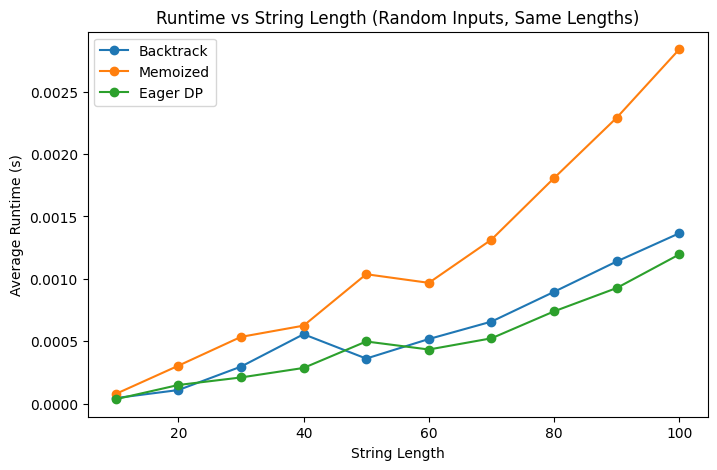

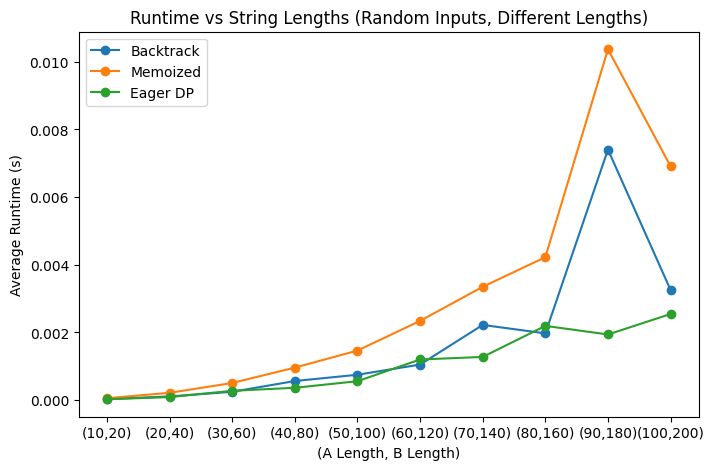

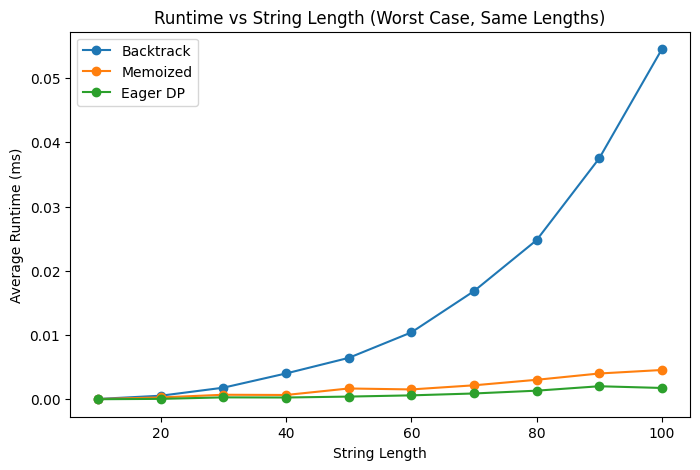

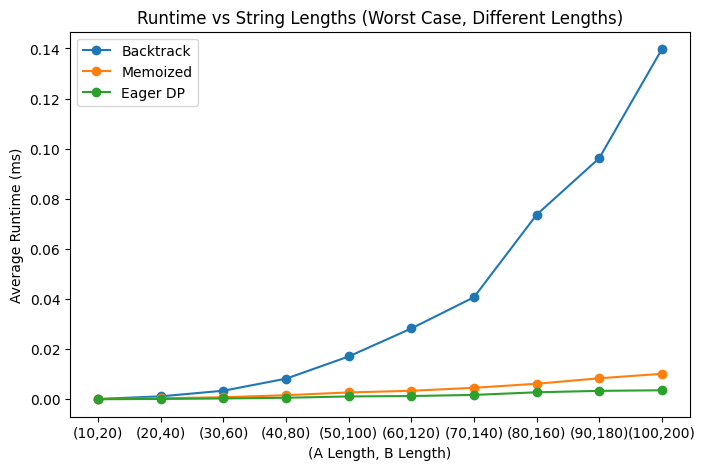

In [69]:
# Graph 1: Random inputs, same lengths
plt.figure(figsize=(8, 5))
plt.plot(same_results1['A Length'], same_results1['Backtrack'], label='Backtrack', marker='o')
plt.plot(same_results1['A Length'], same_results1['Memoized'], label='Memoized', marker='o')
plt.plot(same_results1['A Length'], same_results1['Eager'], label='Eager DP', marker='o')
plt.title('Runtime vs String Length (Random Inputs, Same Lengths)')
plt.xlabel('String Length')
plt.ylabel('Average Runtime (s)')
plt.legend()

different_labels = [f"({a},{b})" for a, b in zip(different_results1['A Length'], different_results1['B Length'])]

# Graph 2: Random inputs, different lengths
plt.figure(figsize=(8, 5))
plt.plot(different_labels, different_results1['Backtrack'], label='Backtrack', marker='o')
plt.plot(different_labels, different_results1['Memoized'], label='Memoized', marker='o')
plt.plot(different_labels, different_results1['Eager'], label='Eager DP', marker='o')
plt.title('Runtime vs String Lengths (Random Inputs, Different Lengths)')
plt.xlabel('(A Length, B Length)')
plt.ylabel('Average Runtime (s)')
plt.legend()

# Graph 3: Worst-case inputs, same lengths
plt.figure(figsize=(8, 5))
plt.plot(same_results2['A Length'], same_results2['Backtrack'], label='Backtrack', marker='o')
plt.plot(same_results2['A Length'], same_results2['Memoized'], label='Memoized', marker='o')
plt.plot(same_results2['A Length'], same_results2['Eager'], label='Eager DP', marker='o')
plt.title('Runtime vs String Length (Worst Case, Same Lengths)')
plt.xlabel('String Length')
plt.ylabel('Average Runtime (ms)')
plt.legend()

# Graph 4: Worst-case inputs, different lengths
plt.figure(figsize=(8, 5))
plt.plot(different_labels, different_results2['Backtrack'], label='Backtrack', marker='o')
plt.plot(different_labels, different_results2['Memoized'], label='Memoized', marker='o')
plt.plot(different_labels, different_results2['Eager'], label='Eager DP', marker='o')
plt.title('Runtime vs String Lengths (Worst Case, Different Lengths)')
plt.xlabel('(A Length, B Length)')
plt.ylabel('Average Runtime (ms)')
plt.legend()

plt.show()

### Reflection

Our benchmarking results show the difference between random inputs and worst-case inputs.

For random inputs, all three algorithms grow at a fairly similar rate. This shows that, on average, backtracking isn't much worse since most strings don't have long, matching substrings. 

For the worst-case inputs (identical strings), the results clearly match our runtime analyses. Backtracking is forced to make many more recursive calls, and grows much faster than the other two. While the memoized and eager algorithms grow much slower. 

Across both cases, our eager, dynamic approach is consistently the fastest due to lower overhead.